
#  Adult Income Predict Using Machine Learning
## Complete End-to-End Data Mining Project

This notebook includes:

- Data Loading
- Exploratory Data Analysis (EDA)
- Descriptive Statistics
- Inferential Statistics
- Data Preprocessing
- Feature Scaling
- Multiple ML Models
- Model Evaluation
- Model Comparison

Dataset:
- Adult Dataset


In [1]:
# Import liabraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Data load

da = pd.read_csv("adult.csv")

In [3]:
da.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


# Initial Data Exploration

| Column            | Description                                                    |
| ----------------- | -------------------------------------------------------------- |
| `age`             | Age of the individual                                          |
| `workclass`       | Type of employment or work sector                              |
| `fnlwgt`          | Final weight assigned by the census bureau                     |
| `education`       | Highest level of education achieved                            |
| `educational-num` | Numerical representation of education level                    |
| `marital-status`  | Marital status of the individual                               |
| `occupation`      | Type of job or profession                                      |
| `relationship`    | Relationship status within the family                          |
| `race`            | Race category of the individual                                |
| `gender`          | Gender of the individual                                       |
| `capital-gain`    | Profit earned from investments or assets                       |
| `capital-loss`    | Loss from investments or assets                                |
| `hours-per-week`  | Number of working hours per week                               |
| `native-country`  | Country of origin                                              |
| `income`          | Target variable indicating whether income is `>50K` or `<=50K` |


In [4]:
# Rename columns name

da.columns = ["age" , "workclass" , "fnlwgt" , "education" , "educational_num" , "marital_status" ,
              "occupation" , "relationship" , "race" , "gender" , "capital_gain" ,
              "capital_loss" , "hours_per_week" , "native_country" , "income"]

In [5]:
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational_num  48842 non-null  int64 
 5   marital_status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital_gain     48842 non-null  int64 
 11  capital_loss     48842 non-null  int64 
 12  hours_per_week   48842 non-null  int64 
 13  native_country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [6]:
# Find null values

da.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational_num    0
marital_status     0
occupation         0
relationship       0
race               0
gender             0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
income             0
dtype: int64

In [7]:
# Find duplicate values

da.duplicated().sum()

np.int64(52)

In [8]:
# Drop duplicates values

da = da.drop_duplicates()

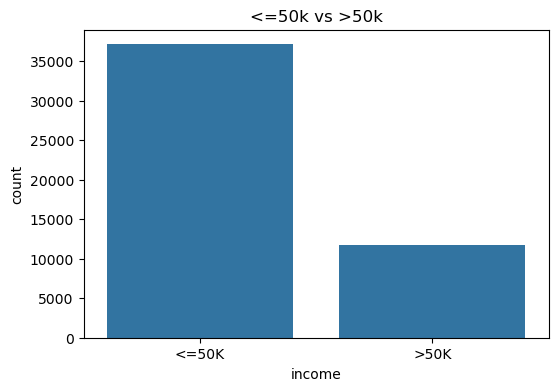

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=da)
plt.title('<=50k vs >50k')
plt.show()

In [10]:
da.describe()

,age,fnlwgt,educational_num,capital_gain,capital_loss,hours_per_week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


<Axes: >

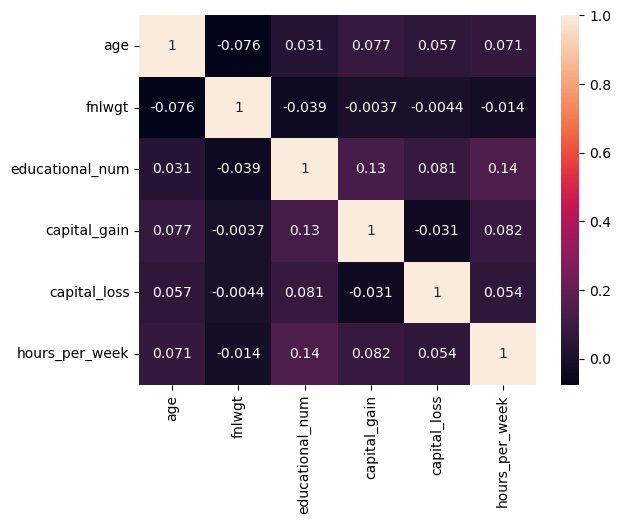

In [11]:
# Check Corr

corr = da.corr(numeric_only = True)
sns.heatmap(corr , annot = True)

In [12]:
(da == '?').sum().sum()

np.int64(6456)

In [13]:
# ? replace to nan 

da.replace('?', np.nan, inplace=True)

In [14]:
# check ? value convert into nan

(da == '?').sum()

age                0
workclass          0
fnlwgt             0
education          0
educational_num    0
marital_status     0
occupation         0
relationship       0
race               0
gender             0
capital_gain       0
capital_loss       0
hours_per_week     0
native_country     0
income             0
dtype: int64

In [15]:
# Find again null values

da.isnull().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational_num       0
marital_status        0
occupation         2805
relationship          0
race                  0
gender                0
capital_gain          0
capital_loss          0
hours_per_week        0
native_country      856
income                0
dtype: int64

In [16]:
# Income columns convert into int 0 : 1

da['income'] = da['income'].replace({"<=50K" : 0 , ">50K" : 1})

In [17]:
# Drop useless columns

da.drop(["native_country" , "fnlwgt"] , axis = 1 , inplace = True)

In [18]:
da.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48790 non-null  int64 
 1   workclass        45995 non-null  object
 2   education        48790 non-null  object
 3   educational_num  48790 non-null  int64 
 4   marital_status   48790 non-null  object
 5   occupation       45985 non-null  object
 6   relationship     48790 non-null  object
 7   race             48790 non-null  object
 8   gender           48790 non-null  object
 9   capital_gain     48790 non-null  int64 
 10  capital_loss     48790 non-null  int64 
 11  hours_per_week   48790 non-null  int64 
 12  income           48790 non-null  int64 
dtypes: int64(6), object(7)
memory usage: 5.2+ MB


In [19]:
x = da.drop("income" , axis = 1)
y = da.income

# LOGISTIC REGRESSION MODEL

In [20]:
# Import train_test_split for splitting data into training and testing sets

from sklearn.model_selection import train_test_split

In [21]:
# Split dataset into training and testing data

X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.30 , random_state = 42)

In [22]:
# Select categorical columns

cat_cols = X_train.select_dtypes('object')

# Select numerical columns

num_cols = X_train.select_dtypes('number')

In [23]:
# Import required libraries for preprocessing and model building

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [24]:
# Create Logistic Regression model

model  = LogisticRegression()

In [25]:
# Numerical pipeline:

num_pipeline = Pipeline([
    ("Imputer" , SimpleImputer(strategy = 'median')),  # fill missing values using median value
    ("Scaling" , StandardScaler())                     # apply feature scaling
                        ])


# Numerical pipeline:

cat_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy = 'most_frequent')),                                         # fill missing values using mode frequent value
    ("Encoding", OneHotEncoder(drop = 'first' , handle_unknown = 'ignore' , sparse_output = False))  # convert categorical data into numerical form
                       ])

In [26]:
# Combine numerical and categorical preprocessing pipelines

preprocessor = ColumnTransformer(
            transformers = [
                ("num" , num_pipeline , num_cols.columns),
                ("cat" , cat_pipeline , cat_cols.columns)
                          ]
                                )

In [27]:
# Create complete machine learning pipeline
# including preprocessing and model training

model_pipeline = Pipeline([
    ("preprocessor" , preprocessor),
    ("Model" , model)
])

In [28]:
# Train the pipeline on training data

model_pipeline.fit(X_train , y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['age', 'educational_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'gender'],
      dtype='object'))])),
                ('Model', LogisticRegression())])

In [29]:
y_pred_test  = model_pipeline.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [31]:
accuracy_score(y_test , y_pred_test)

0.8483295757327322

In [32]:
confusion_matrix(y_test , y_pred_test)

array([[10363,   731],
       [ 1489,  2054]])

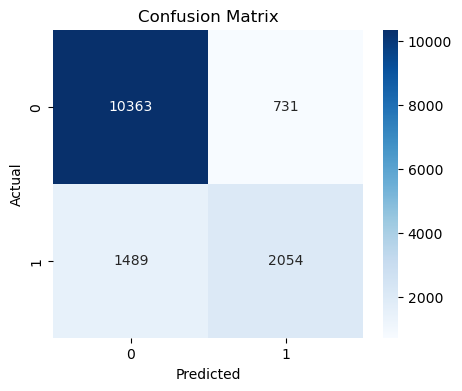

In [33]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [34]:
print(classification_report(y_test , y_pred_test))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90     11094
           1       0.74      0.58      0.65      3543

    accuracy                           0.85     14637
   macro avg       0.81      0.76      0.78     14637
weighted avg       0.84      0.85      0.84     14637



# KNNeighbour MODEL

In [35]:
from sklearn.neighbors import KNeighborsClassifier

In [36]:
# Creat KNNeighborsClassifier Model

model_KN = model_KN = KNeighborsClassifier(n_neighbors = 7)

In [37]:
# Numerical pipeline:

num_pipeline = Pipeline([
    ("Imputer" , SimpleImputer(strategy = 'median')),  # fill missing values using median value
    ("Scaling" , StandardScaler())                     # apply feature scaling
                        ])


# Numerical pipeline:

cat_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy = 'most_frequent')),                                         # fill missing values using mode frequent value
    ("Encoding", OneHotEncoder(drop = 'first' , handle_unknown = 'ignore' , sparse_output = False))  # convert categorical data into numerical form
                       ])

In [38]:
# Combine numerical and categorical preprocessing pipelines

preprocessor = ColumnTransformer(
            transformers = [
                ("num" , num_pipeline , num_cols.columns),
                ("cat" , cat_pipeline , cat_cols.columns)
                          ]
                                )

In [39]:
# Create complete machine learning pipeline
# including preprocessing and model training

model_KN_pipeline = Pipeline([
    ("preprocessor" , preprocessor),
    ("Model" , model_KN)
])

In [40]:
model_KN_pipeline.fit(X_train , y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['age', 'educational_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'gender'],
      dtype='object'))])),
                ('Model', KNeighborsClassifier(n_neighbors=7))])

In [41]:
y_pred_test_KN  = model_KN_pipeline.predict(X_test)

In [42]:
accuracy_score(y_test , y_pred_test_KN)

0.8401994944319191

In [43]:
confusion_matrix(y_test , y_pred_test_KN)

array([[10145,   949],
       [ 1390,  2153]])

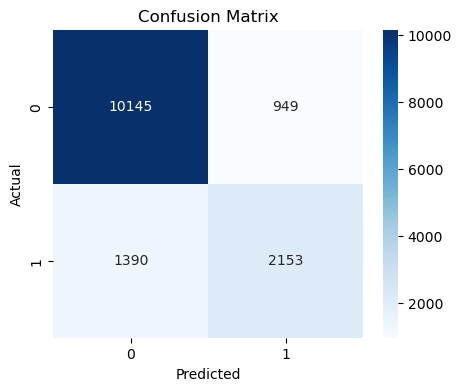

In [44]:
cm = confusion_matrix(y_test, y_pred_test_KN)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
print(classification_report(y_test , y_pred_test_KN))

              precision    recall  f1-score   support

           0       0.88      0.91      0.90     11094
           1       0.69      0.61      0.65      3543

    accuracy                           0.84     14637
   macro avg       0.79      0.76      0.77     14637
weighted avg       0.83      0.84      0.84     14637



# DECISION TREE MODEL

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
# Create DicisionTreeClassifier Model

model_t = DecisionTreeClassifier(max_depth = 5 , random_state = 42)

In [48]:
# Numerical pipeline:

num_pipeline = Pipeline([
    ("Imputer" , SimpleImputer(strategy = 'median')),  # fill missing values using median value
    ("Scaling" , StandardScaler())                     # apply feature scaling
                        ])


# Numerical pipeline:

cat_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy = 'most_frequent')),                                         # fill missing values using mode frequent value
    ("Encoding", OneHotEncoder(drop = 'first' , handle_unknown = 'ignore' , sparse_output = False))  # convert categorical data into numerical form
                       ])

In [49]:
# Combine numerical and categorical preprocessing pipelines

preprocessor = ColumnTransformer(
            transformers = [
                ("num" , num_pipeline , num_cols.columns),
                ("cat" , cat_pipeline , cat_cols.columns)
                          ]
                                )

In [50]:
# Create complete machine learning pipeline
# including preprocessing and model training

model_t_pipeline = Pipeline([
    ("preprocessor" , preprocessor),
    ("Model" , model_t)
])

In [51]:
model_t_pipeline.fit(X_train , y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['age', 'educational_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'gender'],
      dtype='object'))])),
                ('Model',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [52]:
y_pred_test_t  = model_t_pipeline.predict(X_test)

In [53]:
# Accuracy score

accuracy_score(y_test , y_pred_test_t)

0.8492860558857689

In [54]:
# Confusion matrix

confusion_matrix(y_test , y_pred_test_t)

array([[10571,   523],
       [ 1683,  1860]])

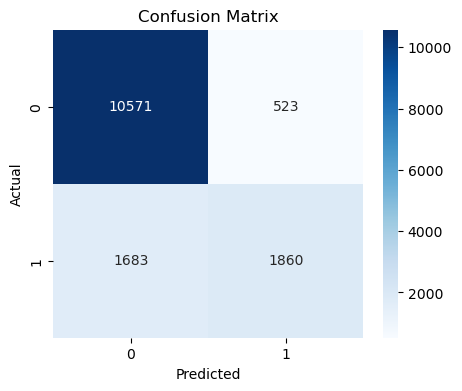

In [55]:
# Confusion matrix visual

cm = confusion_matrix(y_test, y_pred_test_t)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [56]:
# Classification report

print(classification_report(y_test , y_pred_test_t))

              precision    recall  f1-score   support

           0       0.86      0.95      0.91     11094
           1       0.78      0.52      0.63      3543

    accuracy                           0.85     14637
   macro avg       0.82      0.74      0.77     14637
weighted avg       0.84      0.85      0.84     14637



# SVC MODEL

In [57]:
from sklearn.svm import SVC

In [58]:
# Create SVC Model

model_svc = SVC(C=1.0, kernel='rbf')

In [59]:
# Numerical pipeline:

num_pipeline = Pipeline([
    ("Imputer" , SimpleImputer(strategy = 'median')),  # fill missing values using median value
    ("Scaling" , StandardScaler())                     # apply feature scaling
                        ])


# Numerical pipeline:

cat_pipeline = Pipeline([
    ("imputer" , SimpleImputer(strategy = 'most_frequent')),                                         # fill missing values using mode frequent value
    ("Encoding", OneHotEncoder(drop = 'first' , handle_unknown = 'ignore' , sparse_output = False))  # convert categorical data into numerical form
                       ])

In [60]:
# Combine numerical and categorical preprocessing pipelines

preprocessor = ColumnTransformer(
            transformers = [
                ("num" , num_pipeline , num_cols.columns),
                ("cat" , cat_pipeline , cat_cols.columns)
                          ]
                                )

In [61]:
# Create complete machine learning pipeline
# including preprocessing and model training

model_svc_pipeline = Pipeline([
    ("preprocessor" , preprocessor),
    ("Model" , model_svc)
])

In [62]:
# model fit training data

model_svc_pipeline.fit(X_train , y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['age', 'educational_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encoding',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'gender'],
      dtype='object'))])),
                ('Model', SVC())])

In [63]:
# model predict on test

y_pred_test_svc  = model_svc_pipeline.predict(X_test)

In [64]:
# accuracy score

accuracy_score(y_test , y_pred_test_svc)

0.8542734166837467

In [65]:
# confusion matrix

confusion_matrix(y_test , y_pred_test_svc)

array([[10484,   610],
       [ 1523,  2020]])

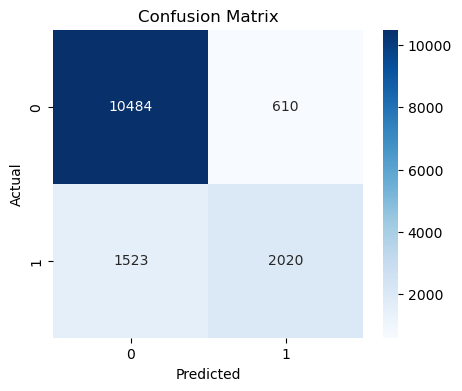

In [66]:
# confusion matrix visual

cm = confusion_matrix(y_test, y_pred_test_svc)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [67]:
# classification Report

print(classification_report(y_test , y_pred_test_svc))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     11094
           1       0.77      0.57      0.65      3543

    accuracy                           0.85     14637
   macro avg       0.82      0.76      0.78     14637
weighted avg       0.85      0.85      0.85     14637



In [68]:
# models comparing

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVC"
    ],

    "Test Accuracy": [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test, y_pred_test_KN),
        accuracy_score(y_test, y_pred_test_t),
        accuracy_score(y_test, y_pred_test_svc)
    ]
})

print(results)

                 Model  Test Accuracy
0  Logistic Regression       0.848330
1                  KNN       0.840199
2        Decision Tree       0.849286
3                  SVC       0.854273


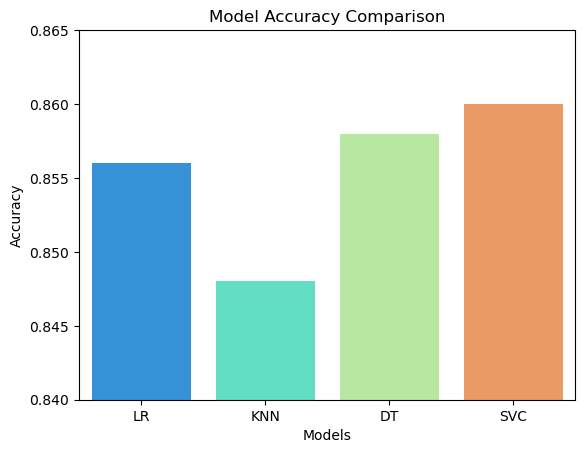

In [69]:
# models compare by sns

models = ['LR', 'KNN', 'DT', 'SVC']

scores = [
    0.856,
    0.848,
    0.858,
    0.860
]

sns.barplot(x=models, y=scores , palette = 'rainbow')

plt.ylim(0.84, 0.865)   # zoomed scale
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")


plt.show()

In [70]:
# model save

with open("model.pkl", "wb") as file:
    pickle.dump(model_svc_pipeline, file)

In [71]:
# model Read

with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

In [ ]:
# model Testing

pred = loaded_model.predict(X_test)

In [ ]:
# model predict result

print(pred[:20])

In [ ]:
# actual result

y_test.head(20)

# Conclusion

Key Findings:
       
- Multiple Machine Learning classification models were trained and evaluated on the Adult Income dataset.
- Among all models, the SVC model achieved the highest accuracy.
- Data preprocessing techniques such as handling missing values, feature scaling, and encoding categorical variables significantly improved model          performance.       
- Pipeline implementation helped automate preprocessing and prediction steps efficiently.
- The trained model was successfully integrated with FastAPI and Streamlit for real-time income prediction.
